In [27]:
# MILESTONE 4: Model Optimization — Overcoming Overfitting

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, learning_curve
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Optimized model (constrained)
rf_opt = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_opt.fit(X_train, y_train)

print("Models trained.")

Models trained.


In [30]:
#Compare metrics: Before vs After
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Baseline RF', rf_model), ('Optimized RF', rf_opt)]:
    y_tr_pred  = model.predict(X_train)
    y_te_pred  = model.predict(X_test)
    y_te_proba = model.predict_proba(X_test)[:, 1]
    cv_acc     = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

    results.append({
        'Model'        : name,
        'Train Acc'    : accuracy_score(y_train, y_tr_pred),
        'Test Acc'     : accuracy_score(y_test,  y_te_pred),
        'Test F1'      : f1_score(y_test, y_te_pred),
        'Test Precision': precision_score(y_test, y_te_pred),
        'Test Recall'  : recall_score(y_test, y_te_pred),
        'ROC-AUC'      : roc_auc_score(y_test, y_te_proba),
        'CV Mean Acc'  : cv_acc.mean(),
        'CV Std'       : cv_acc.std(),
        'Overfit Gap'  : accuracy_score(y_train, y_tr_pred) - accuracy_score(y_test, y_te_pred)
    })

compare_df = pd.DataFrame(results).set_index('Model')
print(compare_df.round(4).to_string())

              Train Acc  Test Acc  Test F1  Test Precision  Test Recall  ROC-AUC  CV Mean Acc  CV Std  Overfit Gap
Model                                                                                                             
Baseline RF      1.0000    0.8533   0.8720          0.8440        0.902   0.9275       0.8180  0.0143       0.1467
Optimized RF     0.8845    0.8478   0.8679          0.8364        0.902   0.9371       0.8234  0.0169       0.0367


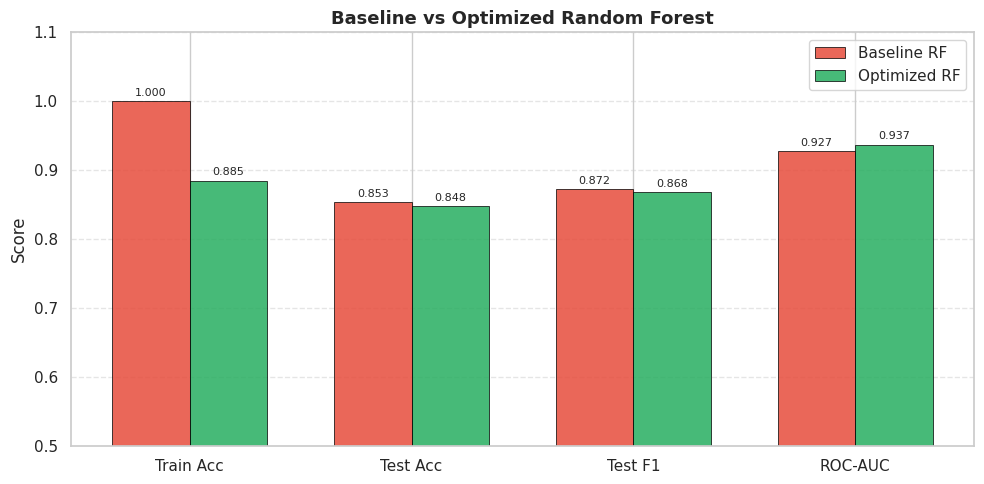

In [31]:
# VISUALIZATION 1: Before vs After Bar Chart
metrics_to_plot = ['Train Acc', 'Test Acc', 'Test F1', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, compare_df.loc['Baseline RF',  metrics_to_plot], width,
               label='Baseline RF',  color='#E74C3C', edgecolor='black', linewidth=0.6, alpha=0.85)
bars2 = ax.bar(x + width/2, compare_df.loc['Optimized RF', metrics_to_plot], width,
               label='Optimized RF', color='#27AE60', edgecolor='black', linewidth=0.6, alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.5, 1.10)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Optimized Random Forest', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m4_before_after_comparison.png', dpi=150)
plt.show()

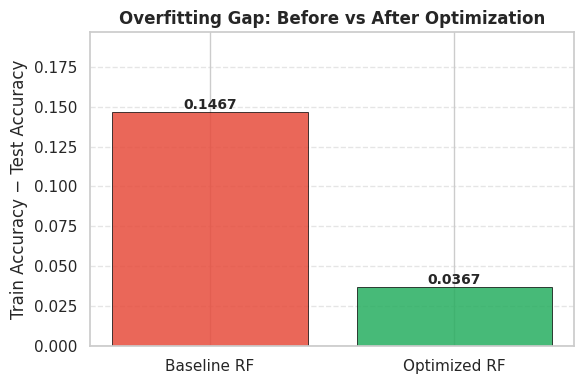

In [32]:
#VISUALIZATION 2: Overfitting Gap
gaps  = [compare_df.loc['Baseline RF', 'Overfit Gap'],
         compare_df.loc['Optimized RF', 'Overfit Gap']]
colors = ['#E74C3C', '#27AE60']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Baseline RF', 'Optimized RF'], gaps, color=colors,
              edgecolor='black', linewidth=0.6, alpha=0.85)
for bar, val in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Train Accuracy − Test Accuracy')
ax.set_title('Overfitting Gap: Before vs After Optimization', fontsize=12, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(0, max(gaps) + 0.05)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m4_overfit_gap.png', dpi=150)
plt.show()

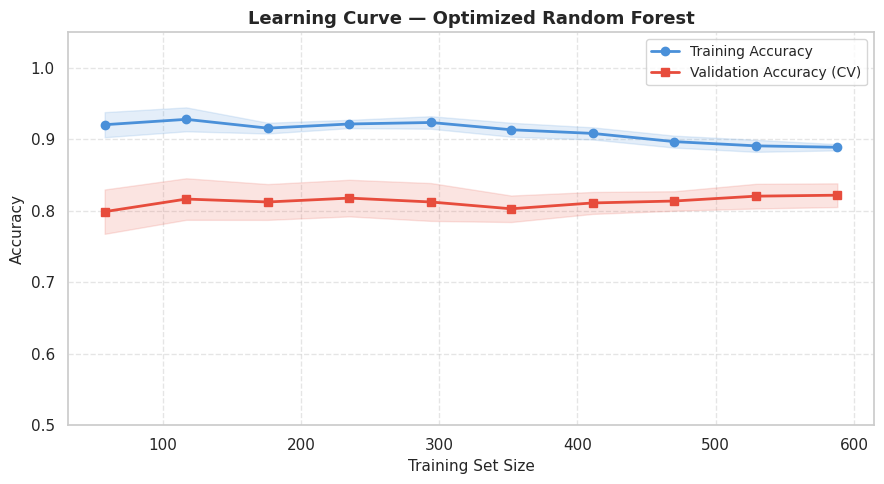


Milestone 4 complete.


In [33]:
# ── 6. VISUALIZATION 3: Learning Curve (Optimized model) ───
train_sizes, train_scores, val_scores = learning_curve(
    rf_opt, X_train, y_train,
    cv=cv, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-',
        color='#4A90D9', label='Training Accuracy', linewidth=2)
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='#4A90D9')
ax.plot(train_sizes, val_scores.mean(axis=1), 's-',
        color='#E74C3C', label='Validation Accuracy (CV)', linewidth=2)
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.15, color='#E74C3C')
ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Learning Curve — Optimized Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m4_learning_curve_optimized.png', dpi=150)
plt.show()

print("\nMilestone 4 complete.")